In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
titanic = pd.read_csv('Titanic-Dataset (1).csv')

Task 3: Explore the Data

In [3]:
titanic.head()
titanic.info()
titanic.describe()
titanic.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

xploratory Data Analysis (EDA)

In [4]:
sns.countplot(x='Survived', data=titanic)
sns.countplot(x='Survived', hue='Sex', data=titanic)
sns.histplot(titanic['Age'].dropna(), bins=30)
sns.boxplot(x='Pclass', y='Age', data=titanic)

<Axes: xlabel='Survived', ylabel='count'>

Data Cleaning

In [5]:
titanic.isnull().sum()
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
titanic.drop('Cabin', axis=1, inplace=True)
titanic.dropna(inplace=True)

Convert Categorical Variables

In [6]:
sex = pd.get_dummies(titanic['Sex'], drop_first=True)
embarked = pd.get_dummies(titanic['Embarked'], drop_first=True)
titanic = pd.concat([titanic, sex, embarked], axis=1)
titanic.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)

Define Features and Target

In [7]:
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

Split the Data

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

Train the Model

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Make Predictions

In [10]:
predictions = model.predict(X_test)

regression metrics

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[134  23]
 [ 35  75]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       157
           1       0.77      0.68      0.72       110

    accuracy                           0.78       267
   macro avg       0.78      0.77      0.77       267
weighted avg       0.78      0.78      0.78       267



Correlation with Target (Survived)

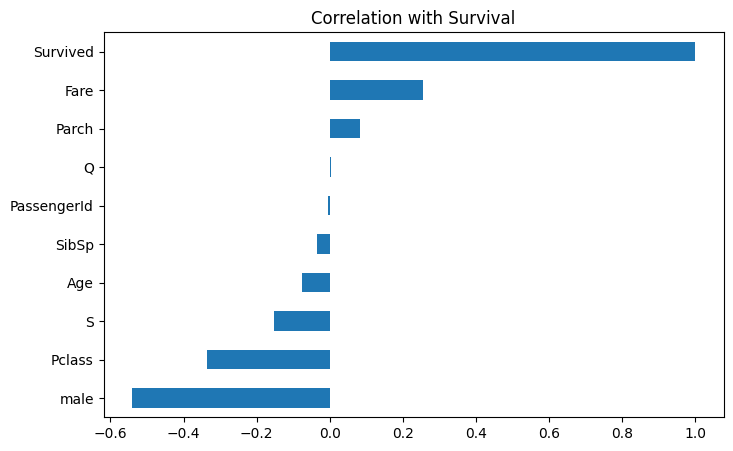

In [15]:
plt.figure(figsize=(8,5))
titanic.corr()['Survived'].sort_values().plot(kind='barh')
plt.title('Correlation with Survival')
plt.show()

Predicted vs Actual

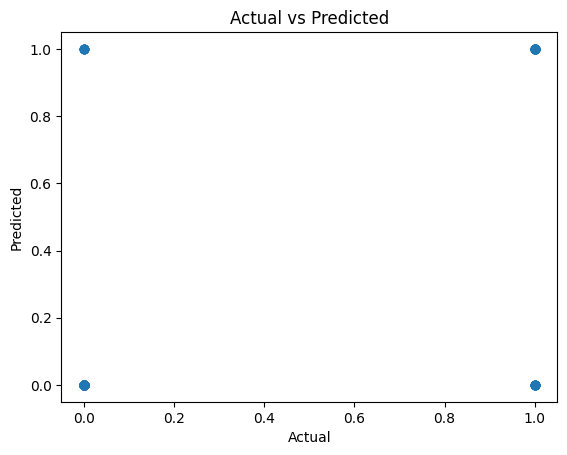

In [18]:
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

Residual Plot

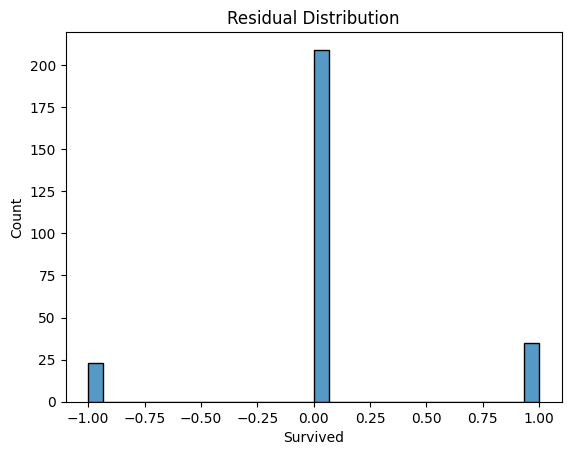

In [17]:
sns.histplot((y_test - predictions), bins=30)
plt.title('Residual Distribution')
plt.show()